In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
data = pd.read_csv("concrete_data.csv")

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Cement              1030 non-null   float64
 1   Blast Furnace Slag  1030 non-null   float64
 2   Fly Ash             1030 non-null   float64
 3   Water               1030 non-null   float64
 4   Superplasticizer    1030 non-null   float64
 5   Coarse Aggregate    1030 non-null   float64
 6   Fine Aggregate      1030 non-null   float64
 7   Age                 1030 non-null   int64  
 8   Strength            1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


In [6]:
data.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [7]:
data.corr()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
Cement,1.000000,-0.275216,-0.397467,-0.081587,0.092386,-0.109349,-0.222718,0.081946,0.497832
Blast Furnace Slag,-0.275216,1.000000,-0.323580,0.107252,0.043270,-0.283999,-0.281603,-0.044246,0.134829
Fly Ash,-0.397467,-0.323580,1.000000,-0.256984,0.377503,-0.009961,0.079108,-0.154371,-0.105755
Water,-0.081587,0.107252,-0.256984,1.000000,-0.657533,-0.182294,-0.450661,0.277618,-0.289633
Superplasticizer,0.092386,0.043270,0.377503,-0.657533,1.000000,-0.265999,0.222691,-0.192700,0.366079
Coarse Aggregate,-0.109349,-0.283999,-0.009961,-0.182294,-0.265999,1.000000,-0.178481,-0.003016,-0.164935
Fine Aggregate,-0.222718,-0.281603,0.079108,-0.450661,0.222691,-0.178481,1.000000,-0.156095,-0.167241
Age,0.081946,-0.044246,-0.154371,0.277618,-0.192700,-0.003016,-0.156095,1.000000,0.328873
Strength,0.497832,0.134829,-0.105755,-0.289633,0.366079,-0.164935,-0.167241,0.328873,1.000000


<Axes: >

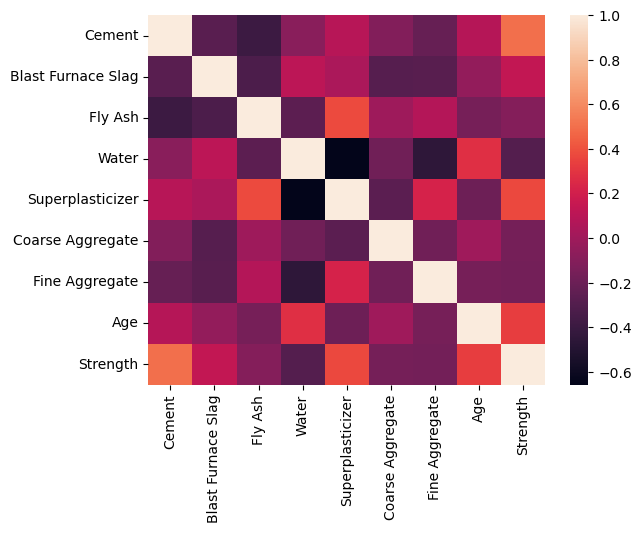

In [8]:
sns.heatmap(data.corr())

<Axes: xlabel='Cement', ylabel='Strength'>

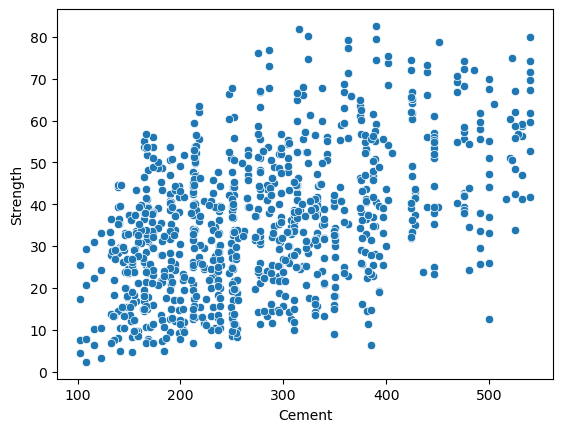

In [9]:
sns.scatterplot(x=data["Cement"],y=data["Strength"])

In [10]:
X = data.drop("Strength",axis=1)
y = data["Strength"]

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=15)

In [13]:
from sklearn.ensemble import GradientBoostingRegressor

In [14]:
gbr = GradientBoostingRegressor(n_estimators=3,max_depth=3,)

In [15]:
gbr.fit(X_train,y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,3
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [16]:
y_pred = gbr.predict(X_test)

In [17]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [18]:
print(r2_score(y_test,y_pred))

0.31963528278555353


In [19]:
gbr = GradientBoostingRegressor()
gbr.fit(X_train,y_train)
y_pred = gbr.predict(X_test)
print(r2_score(y_test,y_pred))

0.9294611003783457


In [20]:
from sklearn.model_selection import RandomizedSearchCV

In [25]:
param = {
    "n_estimators" : [100,150,200,250],
    "max_depth" : [3,4,5],
    "loss" : ["squared_error","absolute_error","huber","quantile"],
    "learning_rate" : [0.01,0.1,0.5]
}

In [26]:
rsv = RandomizedSearchCV(param_distributions=param,estimator=GradientBoostingRegressor())

In [27]:
rsv.fit(X_train,y_train)

,estimator,GradientBoostingRegressor()
,param_distributions,"{'learning_rate': [0.01, 0.1, ...], 'loss': ['squared_error', 'absolute_error', ...], 'max_depth': [3, 4, ...], 'n_estimators': [100, 150, ...]}"
,n_iter,10
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [31]:
rsv.best_params_
rsv.best_score_

np.float64(0.9093299281764422)

In [29]:
rsv_2 = GradientBoostingRegressor(n_estimators=250,max_depth=3,loss="squared_error",learning_rate=0.1)

In [32]:
rsv_2.fit(X_train,y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,250
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [35]:
y_pred = rsv_2.predict(X_test)

In [36]:
print(r2_score(y_test,y_pred))

0.9504140240088237
